# Delivery Time Prediction — Feature Engineering

**Input:** `train_clean.csv` / `test_clean.csv`  
**Output:** `train_features.csv` / `test_features.csv`

**Features built:**
- `same_city` — seller and customer in same city
- `is_weekend` — order placed on Saturday or Sunday
- `purchase_month` — month of order placement
- `approval_lag_hours` — hours between purchase and approval
- `same_day_approval` — approved the same day as purchase
- `distance_km` — haversine distance between seller and customer
- `product_density` — product_weight_g / volume_cm3
- `seller_mean_delivery` — mean delivery time per seller
- `seller_pending_orders` — orders placed by same seller on same day

Categorical columns (`product_category_name_english`, `customer_city`, `seller_city`) are kept as-is and passed to LightGBM natively.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TARGET = 'delivery_time_days'
CAT_COLS = ['product_category_name_english', 'customer_city', 'seller_city']

print('Setup complete ✓')

/Users/anas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete ✓


---
## 1. Load cleaned data

In [2]:
train = pd.read_csv('dataset/processed/train_clean.csv')
test  = pd.read_csv('dataset/processed/test_clean.csv')

for col in ['order_purchase_timestamp', 'order_approved_at']:
    for df in (train, test):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

GLOBAL_MEAN = train[TARGET].mean()

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')

Train : (83401, 16)
Test  : (15029, 15)


---
## 2. Boolean — `same_city`

In [3]:
for df in (train, test):
    df['same_city'] = (
        df['customer_city'].str.lower().str.strip() ==
        df['seller_city'].str.lower().str.strip()
    ).astype(int)

print(f'same_city rate — train : {train["same_city"].mean()*100:.1f}%')
print(f'same_city rate — test  : {test["same_city"].mean()*100:.1f}%')

same_city rate — train : 4.9%
same_city rate — test  : 6.6%


---
## 3. Temporal — `is_weekend`, `purchase_month`

In [4]:
for df in (train, test):
    df['is_weekend']     = (df['order_purchase_timestamp'].dt.dayofweek >= 5).astype(int)
    df['purchase_month'] = df['order_purchase_timestamp'].dt.month

print(f'is_weekend rate — train : {train["is_weekend"].mean()*100:.1f}%')
print(f'purchase_month  — train : {train["purchase_month"].value_counts().sort_index().to_dict()}')

is_weekend rate — train : 23.0%
purchase_month  — train : {1: 7928, 2: 8236, 3: 9639, 4: 9281, 5: 10519, 6: 7462, 7: 3964, 8: 4274, 9: 4215, 10: 4867, 11: 7470, 12: 5546}


---
## 4. Approval — `approval_lag_hours`, `same_day_approval`

In [5]:
for df in (train, test):
    lag = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
    df['approval_lag_hours'] = lag.clip(lower=0)
    df['same_day_approval']  = (
        df['order_purchase_timestamp'].dt.date ==
        df['order_approved_at'].dt.date
    ).astype(int)

print('approval_lag_hours — train:')
print(train['approval_lag_hours'].describe().round(2).to_string())
print(f'\nsame_day_approval rate — train : {train["same_day_approval"].mean()*100:.1f}%')

approval_lag_hours — train:
count    83401.00
mean        10.16
std         20.50
min          0.00
25%          0.00
50%          1.00
75%         14.00
max        741.00

same_day_approval rate — train : 69.6%


---
## 5. Distance — `distance_km`

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

for df in (train, test):
    df['distance_km'] = haversine_km(
        df['customer_lat'], df['customer_lng'],
        df['seller_lat'],   df['seller_lng']
    )

print('distance_km — train:')
print(train['distance_km'].describe().round(1).to_string())

distance_km — train:
count    83401.0
mean       606.6
std        592.0
min          0.0
25%        205.9
50%        440.8
75%        802.6
max       5338.6


---
## 6. Product density — `product_density`

In [7]:
for df in (train, test):
    df['product_density'] = (
        df['product_weight_g'] / df['volume_cm3'].replace(0, np.nan)
    )
    df['product_density'].fillna(df['product_density'].median(), inplace=True)

print('product_density — train:')
print(train['product_density'].describe().round(4).to_string())

product_density — train:
count    83401.0000
mean         0.7576
std          0.0998
min          0.1256
25%          0.6922
50%          0.7495
75%          0.8251
max          1.7135


---
## 7. Seller aggregations

> ⚠️ Computed on the full training set. Recompute inside each CV fold in the modelling notebook to avoid target leakage.

### 7a. `seller_mean_delivery`

In [8]:
seller_mean = (
    train.groupby('seller_id')[TARGET]
         .mean()
         .rename('seller_mean_delivery')
         .reset_index()
)

train = train.merge(seller_mean, on='seller_id', how='left')
test  = test.merge(seller_mean,  on='seller_id', how='left')

train['seller_mean_delivery'].fillna(GLOBAL_MEAN, inplace=True)
test['seller_mean_delivery'].fillna(GLOBAL_MEAN,  inplace=True)

unseen = (~test['seller_id'].isin(train['seller_id'])).sum()
print(f'Unseen sellers in test filled with global mean: {unseen}')
print(train['seller_mean_delivery'].describe().round(2).to_string())

Unseen sellers in test filled with global mean: 1671
count    83401.00
mean        13.05
std          3.03
min          1.04
25%         11.08
50%         12.87
75%         14.74
max         47.22


### 7b. `seller_pending_orders`

In [9]:
for df in (train, test):
    df['_purchase_date'] = df['order_purchase_timestamp'].dt.date

seller_daily = (
    train.groupby(['seller_id', '_purchase_date'])
         .size()
         .rename('seller_pending_orders')
         .reset_index()
)

train = train.merge(seller_daily, on=['seller_id', '_purchase_date'], how='left')
test  = test.merge(seller_daily,  on=['seller_id', '_purchase_date'], how='left')

train['seller_pending_orders'].fillna(1, inplace=True)
test['seller_pending_orders'].fillna(1,  inplace=True)

for df in (train, test):
    df.drop(columns=['_purchase_date'], inplace=True)

print('seller_pending_orders — train:')
print(train['seller_pending_orders'].describe().round(2).to_string())

seller_pending_orders — train:
count    83401.00
mean         2.60
std          3.84
min          1.00
25%          1.00
50%          1.00
75%          3.00
max         78.00


---
## 8. Cast categoricals for LightGBM

In [10]:
for col in CAT_COLS:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

print(f'Cast to category: {CAT_COLS}')

Cast to category: ['product_category_name_english', 'customer_city', 'seller_city']


---
## 9. Drop raw columns

In [11]:
COLS_TO_DROP = [
    'order_purchase_timestamp',       # → is_weekend, purchase_month, approval_lag_hours, same_day_approval
    'order_approved_at',              # → approval_lag_hours, same_day_approval
    'customer_lat', 'customer_lng',   # → distance_km
    'seller_lat',   'seller_lng',     # → distance_km
    'seller_id',                      # → seller_mean_delivery, seller_pending_orders
]

train = train.drop(columns=[c for c in COLS_TO_DROP if c in train.columns])
test  = test.drop(columns=[c for c in COLS_TO_DROP if c in test.columns])

feature_cols = [c for c in train.columns if c != TARGET]
test = test[feature_cols]

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')

Train : (83401, 18)
Test  : (15029, 17)

Features (17): ['customer_city', 'seller_city', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'same_city', 'is_weekend', 'purchase_month', 'approval_lag_hours', 'same_day_approval', 'distance_km', 'product_density', 'seller_mean_delivery', 'seller_pending_orders']


---
## 10. Validation

In [12]:
assert train.isnull().sum().sum() == 0,          'Missing values in train!'
assert test.isnull().sum().sum()  == 0,          'Missing values in test!'
assert TARGET not in test.columns,               'Target leaking into test!'
assert list(feature_cols) == list(test.columns), 'Feature mismatch!'
assert np.isinf(train.select_dtypes(include=np.number).values).sum() == 0, 'Inf in train!'
assert np.isinf(test.select_dtypes(include=np.number).values).sum()  == 0, 'Inf in test!'

print('All validation checks passed ✓')
print(f'Test rows preserved: {len(test):,}')

All validation checks passed ✓
Test rows preserved: 15,029


---
## 11. Correlation matrix (numeric features only)

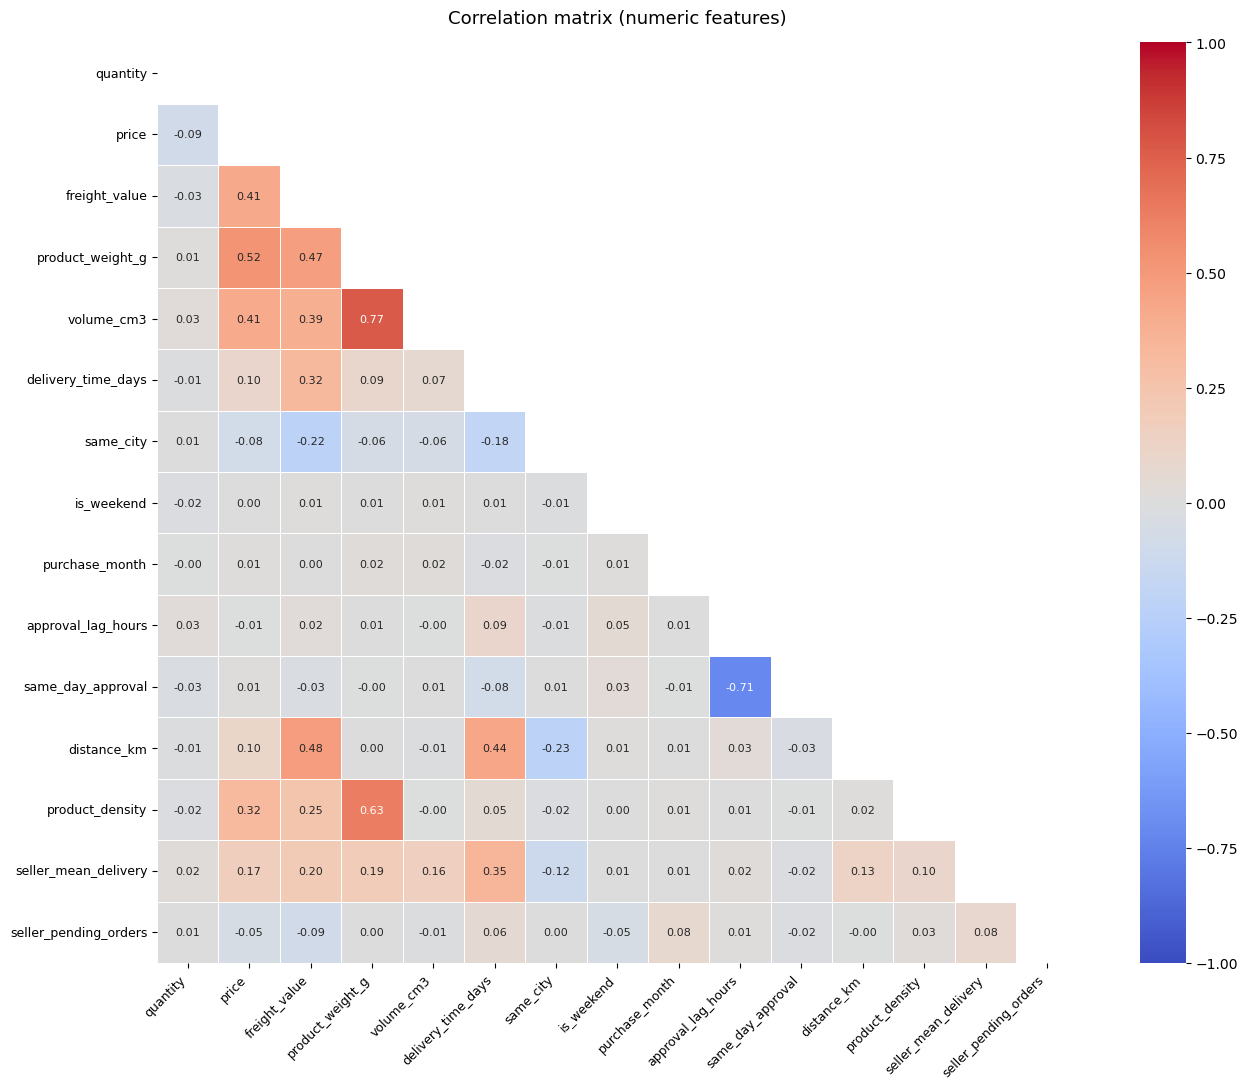


Correlations with target:


,delivery_time_days
distance_km,0.435
seller_mean_delivery,0.349
freight_value,0.324
price,0.098
approval_lag_hours,0.095
product_weight_g,0.086
volume_cm3,0.069
seller_pending_orders,0.062
product_density,0.050
is_weekend,0.006


In [13]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 8}, cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True, ax=ax
)
ax.set_title('Correlation matrix (numeric features)', fontsize=13, pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
import os; os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCorrelations with target:')
display(
    corr[[TARGET]].drop(TARGET)
                  .sort_values(TARGET, ascending=False)
                  .round(3)
)

---
## 12. Save

In [14]:
import os
os.makedirs('dataset/processed', exist_ok=True)

train.to_csv('dataset/processed/train_features.csv', index=False)
test.to_csv( 'dataset/processed/test_features.csv',  index=False)

print('Saved train_features.csv ✓')
print('Saved test_features.csv  ✓')

Saved train_features.csv ✓
Saved test_features.csv  ✓
